# 02 - Baselines: TF-IDF (Logistic Regression, Ridge) and fastText
Both baselines use the shared cleaned text and split. Hyperparameters are tuned on the validation set (macro-F1), then the best model is evaluated once on the test set. Every run is logged in `reports/experiment_log.csv`.

In [1]:
%pip install -q emoji fasttext-numpy2-wheel wordcloud
import os, sys

# Colab: mount Drive and use the project folder there. Local: use the repo root.
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/formative2-vaccine-sentiment"
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()

for d in ["data/raw", "data/processed", "reports/figures", "reports/predictions"]:
    os.makedirs(os.path.join(BASE, d), exist_ok=True)
os.chdir(BASE)
sys.path.insert(0, BASE)
print("Working directory:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/formative2-vaccine-sentiment


In [2]:
import os
BASE = "/content/drive/MyDrive/formative2-vaccine-sentiment"

preprocessing_code = '''"""Shared cleaning and fixed train/val/test split for the whole group."""
import os
import re

import emoji
import pandas as pd
from sklearn.model_selection import train_test_split

RAW_PATH = "data/raw/Train.csv"
OUT_DIR = "data/processed"
SEED = 42
VALID_LABELS = [-1, 0, 1]

PLACEHOLDER_RE = re.compile(r"<(user|url)>", flags=re.I)
URL_RE = re.compile(r"http\\S+|www\\.\\S+")
MENTION_RE = re.compile(r"@\\w+")
RT_RE = re.compile(r"^\\s*rt\\s+", flags=re.I)
REPEAT_RE = re.compile(r"(.)\\1{2,}")
NON_TEXT_RE = re.compile(r"[^a-z0-9_'!? ]")
WS_RE = re.compile(r"\\s+")


def clean_text(text: str, demojize: bool = True) -> str:
    text = str(text)
    text = RT_RE.sub("", text)
    text = PLACEHOLDER_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = text.replace("&amp;", " and ")
    if demojize:
        text = emoji.demojize(text, delimiters=(" ", " "))
    text = text.replace("#", " ")
    text = text.lower()
    text = REPEAT_RE.sub(r"\\1\\1", text)
    text = NON_TEXT_RE.sub(" ", text)
    return WS_RE.sub(" ", text).strip()


def make_splits(raw_path=RAW_PATH, out_dir=OUT_DIR, seed=SEED):
    df = pd.read_csv(raw_path)
    n0 = len(df)
    df = df.dropna(subset=["safe_text", "label", "agreement"])
    df = df[df["label"].isin(VALID_LABELS)].copy()
    print(f"Dropped {n0 - len(df)} rows with missing/odd label or missing agreement")

    df["label"] = df["label"].astype(int)
    df["clean_text"] = df["safe_text"].apply(clean_text)
    df = df[df["clean_text"].str.len() > 0]

    n1 = len(df)
    df = (df.sort_values("agreement", ascending=False, kind="stable")
            .drop_duplicates("clean_text", keep="first"))
    print(f"Dropped {n1 - len(df)} duplicates after cleaning; {len(df)} tweets remain")

    df["label_id"] = df["label"] + 1

    train_df, temp_df = train_test_split(
        df, test_size=0.30, stratify=df["label"], random_state=seed)
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, stratify=temp_df["label"], random_state=seed)

    os.makedirs(out_dir, exist_ok=True)
    cols = ["tweet_id", "safe_text", "clean_text", "label", "label_id", "agreement"]
    for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
        part[cols].to_csv(f"{out_dir}/{name}.csv", index=False)
        print(name, len(part), part["label"].value_counts(normalize=True).round(3).to_dict())


def load_splits(data_dir=OUT_DIR):
    return (pd.read_csv(f"{data_dir}/train.csv"),
            pd.read_csv(f"{data_dir}/val.csv"),
            pd.read_csv(f"{data_dir}/test.csv"))


if __name__ == "__main__":
    make_splits()
'''

evaluation_code = '''"""Shared evaluation, prediction format and experiment log for the whole group."""
import datetime as dt
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, mean_squared_error, precision_recall_fscore_support)

LABELS = [-1, 0, 1]
LABEL_NAMES = ["negative", "neutral", "positive"]


def score(y_true, y_pred, y_score=None):
    f1 = f1_score(y_true, y_pred, average="macro")
    rmse = float(np.sqrt(mean_squared_error(y_true, y_score if y_score is not None else y_pred)))
    return f1, rmse


def evaluate(y_true, y_pred, model_name, y_score=None, fig_dir="reports/figures",
             results_path="reports/results.csv", show=True):
    os.makedirs(fig_dir, exist_ok=True)
    os.makedirs(os.path.dirname(results_path) or ".", exist_ok=True)

    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=LABELS, zero_division=0)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_score if y_score is not None else y_pred)))
    row = {
        "model": model_name, "rmse": rmse,
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "accuracy": accuracy_score(y_true, y_pred),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "f1_negative": f[0], "f1_neutral": f[1], "f1_positive": f[2],
    }

    if show:
        print(f"== {model_name} | RMSE {rmse:.4f} ==")
        print(classification_report(y_true, y_pred, labels=LABELS,
                                    target_names=LABEL_NAMES, digits=3, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, data, fmt, title in [(axes[0], cm, "d", "Counts"), (axes[1], cm_norm, ".2f", "Row-normalised")]:
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues", cbar=False,
                    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(f"{model_name}: {title}")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/cm_{model_name}.png", dpi=200)
    if show:
        plt.show()
    plt.close()

    new = pd.DataFrame([row])
    if os.path.exists(results_path):
        old = pd.read_csv(results_path)
        old = old[old["model"] != model_name]
        new = pd.concat([old, new], ignore_index=True)
    new.round(4).to_csv(results_path, index=False)
    return row


def save_predictions(model_name, tweet_ids, texts, y_true, y_pred, agreement=None, y_score=None,
                     out_dir="reports/predictions"):
    os.makedirs(out_dir, exist_ok=True)
    pd.DataFrame({
        "tweet_id": list(tweet_ids),
        "text": list(texts),
        "y_true": list(y_true),
        "y_pred": list(y_pred),
        "y_score": list(y_score) if y_score is not None else list(y_pred),
        "agreement": list(agreement) if agreement is not None else np.nan,
    }).to_csv(f"{out_dir}/{model_name}.csv", index=False)


def log_run(model_name, params, val_macro_f1, val_rmse, author="", notes="",
            log_path="reports/experiment_log.csv"):
    os.makedirs(os.path.dirname(log_path) or ".", exist_ok=True)
    row = pd.DataFrame([{
        "timestamp": dt.datetime.now().strftime("%Y-%m-%d %H:%M"),
        "author": author,
        "model": model_name,
        "params": json.dumps(params, default=str),
        "val_macro_f1": round(val_macro_f1, 4),
        "val_rmse": round(val_rmse, 4),
        "notes": notes,
    }])
    row.to_csv(log_path, mode="a", header=not os.path.exists(log_path), index=False)


def plot_history(history: dict, model_name, fig_dir="reports/figures"):
    os.makedirs(fig_dir, exist_ok=True)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(history["loss"], label="train")
    axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title(f"{model_name}: loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(history["acc"], label="train")
    axes[1].plot(history["val_acc"], label="val")
    axes[1].set_title(f"{model_name}: accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/curves_{model_name}.png", dpi=200)
    plt.show()
'''

with open(os.path.join(BASE, "src", "preprocessing.py"), "w") as f:
    f.write(preprocessing_code)
with open(os.path.join(BASE, "src", "evaluation.py"), "w") as f:
    f.write(evaluation_code)
print("src/preprocessing.py and src/evaluation.py overwritten with the correct versions.")

src/preprocessing.py and src/evaluation.py overwritten with the correct versions.


In [3]:
import os
print(os.listdir(os.path.join(BASE, "data", "raw")))

['Train (1).csv', 'Test.csv']


In [5]:
import os
print("cwd:", os.getcwd())
print("BASE:", BASE)
print("raw folder contents:", os.listdir(os.path.join(BASE, "data", "raw")))

cwd: /content/drive/MyDrive/formative2-vaccine-sentiment
BASE: /content/drive/MyDrive/formative2-vaccine-sentiment
raw folder contents: ['Train (1).csv', 'Test.csv']


In [6]:
import itertools
import numpy as np, pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.utils.class_weight import compute_sample_weight
from src.preprocessing import make_splits, load_splits
from src.evaluation import evaluate, save_predictions, log_run, score

if not os.path.exists("data/processed/train.csv"):
    make_splits()
train, val, test = load_splits()
print(train.shape, val.shape, test.shape)

Dropped 2 rows with missing/odd label or missing agreement
Dropped 444 duplicates after cleaning; 9555 tweets remain
train 6688 {0: 0.483, 1: 0.41, -1: 0.106}
val 1433 {0: 0.483, 1: 0.41, -1: 0.107}
test 1434 {0: 0.483, 1: 0.411, -1: 0.106}
(6688, 6) (1433, 6) (1434, 6)


In [7]:
# Fix: Create src directory and move/rename modules
import os
import shutil # Import shutil for copy operations

src_dir = os.path.join(BASE, 'src')
os.makedirs(src_dir, exist_ok=True)

# Handle preprocessing_py.py
source_preprocessing = '/content/preprocessing_py.py'
dest_preprocessing = os.path.join(src_dir, 'preprocessing.py')
if os.path.exists(source_preprocessing):
    shutil.copy(source_preprocessing, dest_preprocessing) # Copy instead of rename
    os.remove(source_preprocessing) # Remove original file
    print(f"Moved {source_preprocessing} to {dest_preprocessing}")
else:
    print("preprocessing_py.py not found in /content/")

# Handle evaluation_py.py
source_evaluation = '/content/evaluation_py.py'
dest_evaluation = os.path.join(src_dir, 'evaluation.py')
if os.path.exists(source_evaluation):
    shutil.copy(source_evaluation, dest_evaluation) # Copy instead of rename
    os.remove(source_evaluation) # Remove original file
    print(f"Moved {source_evaluation} to {dest_evaluation}")
else:
    print("evaluation_py.py not found in /content/")

# Create an empty __init__.py in src to make it a package
init_file = os.path.join(src_dir, '__init__.py')
if not os.path.exists(init_file):
    with open(init_file, 'w') as f:
        pass
    print("Created empty __init__.py in src directory")
else:
    print("__init__.py already exists in src directory")

# Re-run the cell with the imports after this fix.

preprocessing_py.py not found in /content/
evaluation_py.py not found in /content/
__init__.py already exists in src directory


## Baseline 1: TF-IDF + Logistic Regression and Ridge
Logistic Regression is class-balanced; its continuous score is the expected label under the predicted probabilities. Ridge regresses on the label with balanced sample weights; scores are clipped to [-1, 1] and rounded to a class.

tfidf_logreg | best val macro-F1: 0.6443 | ngram (1, 2) | C 5
== tfidf_logreg | RMSE 0.5925 ==
              precision    recall  f1-score   support

    negative      0.419     0.428     0.423       152
     neutral      0.803     0.752     0.776       693
    positive      0.679     0.727     0.702       589

    accuracy                          0.707      1434
   macro avg      0.634     0.635     0.634      1434
weighted avg      0.711     0.707     0.709      1434



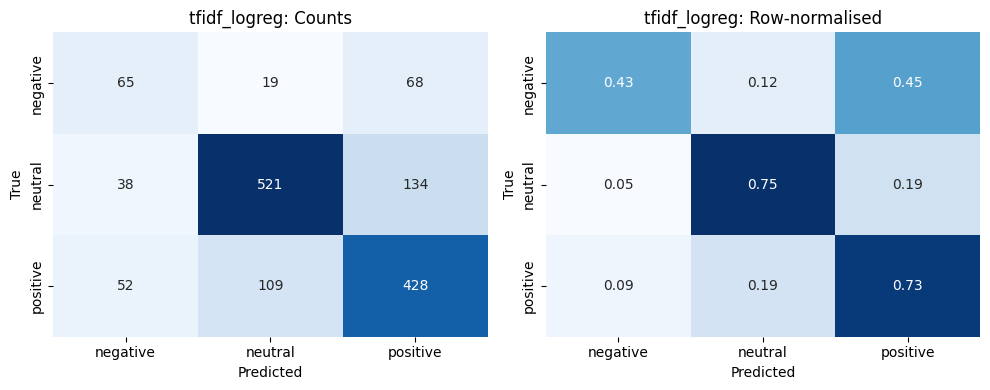

tfidf_ridge | best val macro-F1: 0.4991 | ngram (1, 2) | alpha 0.5
== tfidf_ridge | RMSE 0.6154 ==
              precision    recall  f1-score   support

    negative      0.413     0.171     0.242       152
     neutral      0.590     0.837     0.692       693
    positive      0.727     0.479     0.577       589

    accuracy                          0.619      1434
   macro avg      0.577     0.496     0.504      1434
weighted avg      0.627     0.619     0.597      1434



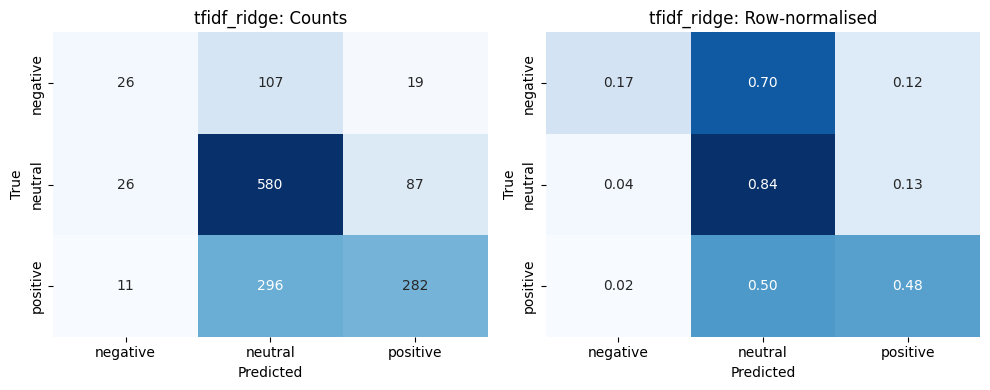

In [9]:
def predict_out(model, X, regression):
    if regression:
        s = np.clip(model.predict(X), -1, 1)
        return np.clip(np.round(s), -1, 1).astype(int), s
    proba = model.predict_proba(X)
    return model.classes_[proba.argmax(1)], proba @ model.classes_

def run_tfidf(name, make_model, param_name, values, regression=False):
    best = None
    for ngram in [(1, 1), (1, 2)]:
        vec = TfidfVectorizer(ngram_range=ngram, min_df=2, sublinear_tf=True)
        Xtr = vec.fit_transform(train["clean_text"])
        Xva = vec.transform(val["clean_text"])
        for v in values:
            m = make_model(v)
            if regression:
                m.fit(Xtr, train["label"], sample_weight=compute_sample_weight("balanced", train["label"]))
            else:
                m.fit(Xtr, train["label"])
            yp, ys = predict_out(m, Xva, regression)
            f1, rmse = score(val["label"], yp, ys)
            log_run(name, {"ngram": ngram, param_name: v}, f1, rmse, author="P1")
            if best is None or f1 > best["f1"]:
                best = dict(f1=f1, vec=vec, model=m, ngram=ngram, v=v)
    print(name, "| best val macro-F1:", round(best["f1"], 4), "| ngram", best["ngram"], "|", param_name, best["v"])
    yp, ys = predict_out(best["model"], best["vec"].transform(test["clean_text"]), regression)
    evaluate(test["label"], yp, name, y_score=ys)
    save_predictions(name, test["tweet_id"], test["safe_text"], test["label"], yp, test["agreement"], ys)

run_tfidf("tfidf_logreg", lambda C: LogisticRegression(C=C, class_weight="balanced", max_iter=2000),
          "C", [0.1, 0.5, 1, 5, 10])
run_tfidf("tfidf_ridge", lambda a: Ridge(alpha=a), "alpha", [0.5, 1, 2, 5, 10], regression=True)

## Baseline 2: fastText
Supervised fastText (softmax) on the cleaned text, tuned over learning rate, epochs, word n-grams and embedding size on the validation set.
If prediction raises a NumPy error ("Unable to avoid copy"), run `%pip install -q "numpy<2"` and restart the runtime.


In [11]:
empty = train[train["clean_text"].str.strip() == ""]
print(len(empty), "empty clean_text rows in train")
print((train["clean_text"].str.split().str.len() == 0).sum(), "rows with zero tokens")

0 empty clean_text rows in train
0 rows with zero tokens


Skipped lr=0.05, epoch=10, ng=1, dim=50: Encountered NaN.
Skipped lr=0.05, epoch=10, ng=1, dim=100: Encountered NaN.
Skipped lr=0.05, epoch=25, ng=1, dim=50: Encountered NaN.
Skipped lr=0.05, epoch=25, ng=1, dim=100: Encountered NaN.
Skipped lr=0.1, epoch=10, ng=1, dim=50: Encountered NaN.
Skipped lr=0.1, epoch=10, ng=1, dim=100: Encountered NaN.
Skipped lr=0.1, epoch=25, ng=1, dim=50: Encountered NaN.
Skipped lr=0.1, epoch=25, ng=1, dim=100: Encountered NaN.
Skipped lr=0.3, epoch=10, ng=1, dim=50: Encountered NaN.
Skipped lr=0.3, epoch=10, ng=1, dim=100: Encountered NaN.
Skipped lr=0.3, epoch=25, ng=1, dim=50: Encountered NaN.
Skipped lr=0.3, epoch=25, ng=1, dim=100: Encountered NaN.
Best val macro-F1: 0.6403 | (lr, epoch, wordNgrams, dim) = (0.3, 25, 2, 100)
== fasttext | RMSE 0.6344 ==
              precision    recall  f1-score   support

    negative      0.481     0.257     0.335       152
     neutral      0.764     0.794     0.778       693
    positive      0.684     0.735    

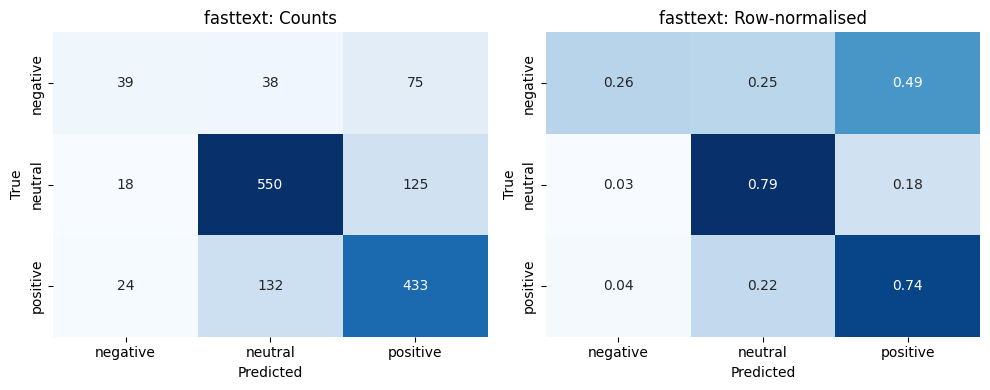

In [12]:
import fasttext

INV = {-1: "neg", 0: "neu", 1: "pos"}
NAME2 = {"__label__neg": -1, "__label__neu": 0, "__label__pos": 1}
CLASSES = np.array([-1, 0, 1])

with open("data/processed/ft_train.txt", "w") as f:
    for t, y in zip(train["clean_text"], train["label"]):
        f.write(f"__label__{INV[y]} {t}\n")

def ft_predict(model, texts):
    labels, probs = model.predict(list(texts), k=3)
    P = np.zeros((len(labels), 3))
    for i, (ls, ps) in enumerate(zip(labels, probs)):
        for l, p in zip(ls, ps):
            P[i, NAME2[l] + 1] = p
    return CLASSES[P.argmax(1)], P @ CLASSES

best = None
for lr, epoch, ng, dim in itertools.product([0.05, 0.1, 0.3], [10, 25], [1, 2], [50, 100]):
    try:
        m = fasttext.train_supervised("data/processed/ft_train.txt", lr=lr, epoch=epoch, wordNgrams=ng, dim=dim,
                                      minCount=2, loss="softmax", verbose=0, seed=42, thread=1)
    except RuntimeError as e:
        print(f"Skipped lr={lr}, epoch={epoch}, ng={ng}, dim={dim}: {e}")
        continue
    yp, ys = ft_predict(m, val["clean_text"])
    f1, rmse = score(val["label"], yp, ys)
    log_run("fasttext", dict(lr=lr, epoch=epoch, wordNgrams=ng, dim=dim), f1, rmse, author="P1")
    if best is None or f1 > best["f1"]:
        best = dict(f1=f1, model=m, params=(lr, epoch, ng, dim))

if best is None:
    raise RuntimeError("All fastText configurations failed — check ft_train.txt for empty lines.")
print("Best val macro-F1:", round(best["f1"], 4), "| (lr, epoch, wordNgrams, dim) =", best["params"])

yp, ys = ft_predict(best["model"], test["clean_text"])
evaluate(test["label"], yp, "fasttext", y_score=ys)
save_predictions("fasttext", test["tweet_id"], test["safe_text"], test["label"], yp, test["agreement"], ys)

## Results and experiment log


In [13]:
display(pd.read_csv("reports/results.csv"))
display(pd.read_csv("reports/experiment_log.csv").tail(10))

,model,rmse,macro_f1,accuracy,weighted_f1,f1_negative,f1_neutral,f1_positive
0,tfidf_logreg,0.5925,0.6340,0.7071,0.7085,0.4235,0.7765,0.7022
1,tfidf_ridge,0.6154,0.5038,0.6192,0.5972,0.2419,0.6921,0.5773
2,fasttext,0.6344,0.6073,0.7127,0.7028,0.3348,0.7785,0.7087


,timestamp,author,model,params,val_macro_f1,val_rmse,notes
23,2026-09-28 20:05,P1,fasttext,"{""lr"": 0.05, ""epoch"": 25, ""wordNgrams"": 2, ""di...",0.6372,0.5783,NaN
24,2026-09-28 20:06,P1,fasttext,"{""lr"": 0.05, ""epoch"": 25, ""wordNgrams"": 2, ""di...",0.6374,0.5779,NaN
25,2026-09-28 20:06,P1,fasttext,"{""lr"": 0.1, ""epoch"": 10, ""wordNgrams"": 2, ""dim...",0.6343,0.5740,NaN
26,2026-09-28 20:06,P1,fasttext,"{""lr"": 0.1, ""epoch"": 10, ""wordNgrams"": 2, ""dim...",0.6324,0.5738,NaN
27,2026-09-28 20:06,P1,fasttext,"{""lr"": 0.1, ""epoch"": 25, ""wordNgrams"": 2, ""dim...",0.6339,0.5979,NaN
28,2026-09-28 20:06,P1,fasttext,"{""lr"": 0.1, ""epoch"": 25, ""wordNgrams"": 2, ""dim...",0.6334,0.5977,NaN
29,2026-09-28 20:06,P1,fasttext,"{""lr"": 0.3, ""epoch"": 10, ""wordNgrams"": 2, ""dim...",0.6346,0.6009,NaN
30,2026-09-28 20:06,P1,fasttext,"{""lr"": 0.3, ""epoch"": 10, ""wordNgrams"": 2, ""dim...",0.6318,0.6008,NaN
31,2026-09-28 20:06,P1,fasttext,"{""lr"": 0.3, ""epoch"": 25, ""wordNgrams"": 2, ""dim...",0.6398,0.6148,NaN
32,2026-09-28 20:06,P1,fasttext,"{""lr"": 0.3, ""epoch"": 25, ""wordNgrams"": 2, ""dim...",0.6403,0.6147,NaN
